## 1. Imports and Packages

In [1]:
import logging
import sys
from dataclasses import dataclass, field
from typing import List

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType, TimestampType
)
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler, VectorAssembler

print("Imports complete")

Imports complete


## 2. Configuration

In [16]:
@dataclass
class PipelineConfig:
    # Data paths
    raw_path: str = "../data/raw/online_retail_II.xlsx"         # put the raw data in this path
    output_dir: str = "../data/outputs/customer_segments"    # output segment will be found here

    # RFM filter
    recency_max_days: int = 365                                 # We will treat valid customers as those who made a purchase in the last year (365 days)       

    # K-Means
    k_range: List[int] = field(default_factory=lambda: list(range(2, 9)))
    seed: int = 42
    max_iter: int = 20
    test_fraction: float = 0.2

    # Spark
    app_name: str = "RFM_Pipeline"
    shuffle_partitions: int = 200

    # Segment label assigned to the highest-value cluster
    top_segment_name: str = "Champions"
    bottom_segment_name: str = "At Risk"

CFG = PipelineConfig()
print(f"Config loaded: Raw data is in {CFG.raw_path} and the output data will be in {CFG.output_dir}")

Config loaded: Raw data is in ../data/raw/online_retail_II.xlsx and the output data will be in ../data/outputs/customer_segments


## 3. Setting Up Logging

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
)
log = logging.getLogger(__name__)
log.info("Logging configured")

22:08:24  INFO      Logging configured


## 4. Schema Definition

In [4]:
RAW_SCHEMA = StructType([
    StructField("Invoice",     StringType(),    True),
    StructField("StockCode",   StringType(),    True),
    StructField("Description", StringType(),    True),
    StructField("Quantity",    IntegerType(),   True),
    StructField("InvoiceDate", TimestampType(), True),
    StructField("Price",       DoubleType(),    True),
    StructField("Customer ID", DoubleType(),    True),  # arrives as float; but should cast to int during cleaning
    StructField("Country",     StringType(),    True),
])

print("Schema defined")

Schema defined


## 5. Start Spark Session

In [5]:
def build_spark() -> SparkSession:
    return (
        SparkSession.builder
        .appName(CFG.app_name)
        .config("spark.driver.host", "127.0.0.1")
        .config("spark.sql.shuffle.partitions", str(CFG.shuffle_partitions))
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .getOrCreate()
    )

spark = build_spark()
spark

26/04/21 22:08:26 WARN Utils: Your hostname, Jonathans-MacBook-Pro-16.local resolves to a loopback address: 127.0.0.1; using 192.168.100.197 instead (on interface en0)
26/04/21 22:08:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/21 22:08:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 4. Ingest Raw Data

In [6]:
def ingest(spark: SparkSession) -> DataFrame:
    pdf = pd.read_excel(CFG.raw_path, engine="openpyxl")
    df = spark.createDataFrame(pdf, schema=RAW_SCHEMA)
    
    df = df.repartition(CFG.shuffle_partitions)   
    log.info("Raw rows: %d  Partitions: %d", df.count(), df.rdd.getNumPartitions())
    return df

df_raw = ingest(spark)
print(f"Raw data loaded: {df_raw.count():,} rows")
df_raw.show(5)

26/04/21 22:09:39 WARN TaskSetManager: Stage 0 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:09:44 WARN TaskSetManager: Stage 6 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:09:46  INFO      Raw rows: 525461  Partitions: 200


26/04/21 22:09:46 WARN TaskSetManager: Stage 7 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:09:48 WARN TaskSetManager: Stage 13 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Raw data loaded: 525,461 rows


+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489539|    22083|PAPER CHAIN KIT R...|     160|2009-12-01 12:18:00| 2.55|    15061.0|United Kingdom|
| 490905|    20727|LUNCH BAG  BLACK ...|       2|2009-12-08 13:08:00| 1.65|    16940.0|United Kingdom|
| 492015|   84031A|CHARLIE+LOLA RED ...|       3|2009-12-15 12:00:00| 4.65|    14911.0|          EIRE|
| 491319|    21832|CHOCOLATE CALCULATOR|      10|2009-12-10 15:33:00| 1.65|    15882.0|United Kingdom|
| 491035|    22073|RETRO SPOT STORAG...|       4|2009-12-09 08:58:00| 3.75|    13455.0|United Kingdom|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
only showing top 5 rows



## 5. Data Cleaning

In [7]:
def clean(df: DataFrame) -> DataFrame:
    raw_count = df.count()
    
    df_clean = (
        df
        .dropDuplicates()
        .filter(
            F.col("Customer ID").isNotNull() &
            F.col("Quantity").isNotNull() &
            F.col("Price").isNotNull() &
            (F.col("Quantity") > 0) &
            (F.col("Price") > 0)
        )
        .withColumn("Customer ID", F.col("Customer ID").cast(IntegerType()))
        .withColumn("TotalPrice",  F.col("Quantity") * F.col("Price"))
        .withColumn("Date",        F.to_date("InvoiceDate"))
    )
    
    clean_count = df_clean.count()
    log.info(
        "Cleaning removed %d rows (%.1f%%). Remaining: %d",
        raw_count - clean_count,
        100 * (raw_count - clean_count) / max(raw_count, 1),
        clean_count,
    )
    return df_clean

df_clean = clean(df_raw)
print(f"Clean data: {df_clean.count():,} rows")
df_clean.show(5)

26/04/21 22:09:51 WARN TaskSetManager: Stage 16 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:09:53 WARN TaskSetManager: Stage 22 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:10:03  INFO      Cleaning removed 20730 rows (3.9%). Remaining: 504731


26/04/21 22:10:03 WARN TaskSetManager: Stage 32 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:10:12 WARN TaskSetManager: Stage 42 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Clean data: 504,731 rows


+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----------+----------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|TotalPrice|      Date|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----------+----------+
| 500656|    22175|   PINK OWL SOFT TOY|       2|2010-03-09 11:19:00| 2.95|      18039|United Kingdom|       5.9|2010-03-09|
| 501907|   85099B|JUMBO BAG RED WHI...|       3|2010-03-21 16:13:00| 1.95|      13451|United Kingdom|      5.85|2010-03-21|
| 504702|    22561|WOODEN SCHOOL COL...|       1|2010-04-15 18:36:00| 1.65|          0|United Kingdom|      1.65|2010-04-15|
| 503790|    22441|GROW YOUR OWN BAS...|       4|2010-04-07 12:45:00|  2.1|      13174|United Kingdom|       8.4|2010-04-07|
| 506562|   85049G|CHOCOLATE BOX RIB...|      12|2010-04-30 12:13:00| 1.25|      16150|United Kingdom|      15.0|2010-04-30|


## 6. Build RFM Features

In [8]:
def build_rfm(df: DataFrame) -> DataFrame:
    max_date = df.agg(F.max("Date").alias("max_date")).collect()[0]["max_date"]
    log.info("RFM snapshot date: %s", max_date)
    
    rfm = (
        df
        .groupBy("Customer ID", "Country")
        .agg(
            F.datediff(F.lit(max_date), F.max("Date")).alias("Recency"),
            F.countDistinct("Invoice").alias("Frequency"),
            F.round(F.sum("TotalPrice"), 2).alias("Monetary"),
        )
        .filter(
            (F.col("Recency") >= 0) &
            (F.col("Recency") <= CFG.recency_max_days)
        )
    )
    
    log.info("RFM customers: %d", rfm.count())
    return rfm

rfm_df = build_rfm(df_clean)
print(f"RFM features: {rfm_df.count():,} customers")
rfm_df.describe().show()

26/04/21 22:10:19 WARN TaskSetManager: Stage 48 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:10:21  INFO      RFM snapshot date: 2010-12-09


26/04/21 22:10:21 WARN TaskSetManager: Stage 54 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:10:28  INFO      RFM customers: 4274


26/04/21 22:10:28 WARN TaskSetManager: Stage 64 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:10:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/21 22:10:35 WARN TaskSetManager: Stage 74 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


RFM features: 4,274 customers


+-------+------------------+-----------+-----------------+-----------------+------------------+
|summary|       Customer ID|    Country|          Recency|        Frequency|          Monetary|
+-------+------------------+-----------+-----------------+-----------------+------------------+
|  count|              4274|       4274|             4274|             4274|              4274|
|   mean|15301.371548900328|       NULL|86.64272344408049|4.887927000467946|2400.0663710809613|
| stddev|1885.6647379258225|       NULL|92.11320917309035|26.89644057436988|23621.675410336047|
|    min|                 0|  Australia|                0|                1|              2.95|
|    max|             18287|West Indies|              365|             1679|        1431040.97|
+-------+------------------+-----------+-----------------+-----------------+------------------+



## 7. Elbow Method to Find Best K

26/04/21 22:10:46 WARN TaskSetManager: Stage 95 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:10:56 WARN TaskSetManager: Stage 116 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:11:05 WARN TaskSetManager: Stage 126 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:11:19 WARN TaskSetManager: Stage 147 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:11:31 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/21 22:11:32 WARN TaskSetManager: Stage 205 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:11:43 WARN TaskSetManager: Stage 226 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:11:52 WARN TaskSetManage

22:12:01  INFO      k=2  silhouette=0.9994


26/04/21 22:12:01 WARN TaskSetManager: Stage 263 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:12:10 WARN TaskSetManager: Stage 284 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:12:18 WARN TaskSetManager: Stage 294 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:12:28 WARN TaskSetManager: Stage 315 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:12:37 WARN TaskSetManager: Stage 391 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:12:46 WARN TaskSetManager: Stage 412 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:12:55 WARN TaskSetManager: Stage 428 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.

22:13:04  INFO      k=3  silhouette=0.9698


26/04/21 22:13:04 WARN TaskSetManager: Stage 449 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:13:13 WARN TaskSetManager: Stage 470 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:13:22 WARN TaskSetManager: Stage 480 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:13:37 WARN TaskSetManager: Stage 501 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:13:49 WARN TaskSetManager: Stage 583 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:14:00 WARN TaskSetManager: Stage 604 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:14:11 WARN TaskSetManager: Stage 620 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.

...

22:16:33  INFO      k=6  silhouette=0.7649


26/04/21 22:16:33 WARN TaskSetManager: Stage 1157 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:16:44 WARN TaskSetManager: Stage 1178 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:16:54 WARN TaskSetManager: Stage 1188 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:17:02 WARN TaskSetManager: Stage 1209 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:17:13 WARN TaskSetManager: Stage 1375 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:17:22 WARN TaskSetManager: Stage 1396 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:17:33 WARN TaskSetManager: Stage 1412 contains a task of very large size (2092 KiB). The maximum recommended task size is 10

22:17:43  INFO      k=7  silhouette=0.6808


26/04/21 22:17:43 WARN TaskSetManager: Stage 1433 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:17:53 WARN TaskSetManager: Stage 1454 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:18:07 WARN TaskSetManager: Stage 1464 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:18:17 WARN TaskSetManager: Stage 1485 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:18:28 WARN TaskSetManager: Stage 1573 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:18:37 WARN TaskSetManager: Stage 1594 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:18:47 WARN TaskSetManager: Stage 1610 contains a task of very large size (2092 KiB). The maximum recommended task size is 10

22:18:56  INFO      k=8  silhouette=0.6489


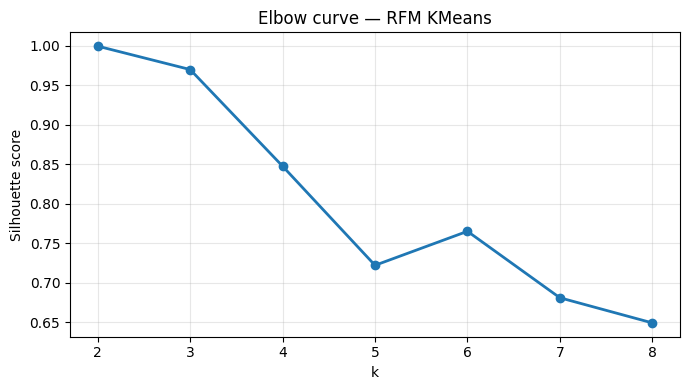

22:18:57  INFO      Elbow curve saved to elbow_curve.png
22:18:57  INFO      Selected k=2 (silhouette=0.9994)
Best k: 2


In [9]:
def select_k(rfm: DataFrame) -> int:
    assembler = VectorAssembler(inputCols=["Recency", "Frequency", "Monetary"], outputCol="features")
    scaler    = StandardScaler(inputCol="features", outputCol="scaledFeatures")
    evaluator = ClusteringEvaluator(featuresCol="scaledFeatures")
    
    scores = {}
    for k in CFG.k_range:
        km       = KMeans(k=k, seed=CFG.seed, maxIter=CFG.max_iter, featuresCol="scaledFeatures")
        pipeline = Pipeline(stages=[assembler, scaler, km])
        preds    = pipeline.fit(rfm).transform(rfm)
        score    = evaluator.evaluate(preds)
        scores[k] = score
        log.info("k=%d  silhouette=%.4f", k, score)
    
    # Plot elbow
    ks, ss = zip(*sorted(scores.items()))
    plt.figure(figsize=(7, 4))
    plt.plot(ks, ss, marker="o", linewidth=2)
    plt.xlabel("k")
    plt.ylabel("Silhouette score")
    plt.title("Elbow curve — RFM KMeans")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("elbow_curve.png", dpi=150, bbox_inches='tight')
    plt.show()
    log.info("Elbow curve saved to elbow_curve.png")
    
    best_k = max(scores, key=scores.__getitem__)
    log.info("Selected k=%d (silhouette=%.4f)", best_k, scores[best_k])
    return best_k

best_k = select_k(rfm_df)
print(f"Best k: {best_k}")

## 10. Fit Model & Label Segments

In [13]:
def fit_and_label(rfm: DataFrame, k: int) -> DataFrame:
    assembler = VectorAssembler(inputCols=["Recency", "Frequency", "Monetary"], outputCol="features")
    scaler    = StandardScaler(inputCol="features", outputCol="scaledFeatures")
    
    # NOTE: I have manually set the k=5 here, based on the elbow curve and business intuition about having 5 meaningful segments
    # Otherwise the previous cell will select the k with the highest silhouette score, which may not always align with business needs for actionable segments
    km        = KMeans(k=5, seed=CFG.seed, maxIter=CFG.max_iter, featuresCol="scaledFeatures")
    pipeline  = Pipeline(stages=[assembler, scaler, km])
    
    train, test = rfm.randomSplit([1 - CFG.test_fraction, CFG.test_fraction], seed=CFG.seed)
    model       = pipeline.fit(train)
    test_preds  = model.transform(test)
    
    evaluator  = ClusteringEvaluator(featuresCol="scaledFeatures")
    silhouette = evaluator.evaluate(test_preds)
    log.info("Test silhouette score: %.4f (>0.5 = good)", silhouette)
    
    all_preds = model.transform(rfm)
    
    # Rank clusters by mean Monetary (descending)
    ltv_ranking = (
        all_preds
        .groupBy("prediction")
        .agg(F.mean("Monetary").alias("avg_ltv"))
        .orderBy(F.desc("avg_ltv"))
        .withColumn("ltv_rank", F.monotonically_increasing_id())
    )
    
    # Map ranks to business-friendly names
    segment_names = {
        0: "Champions",
        1: "Loyal", 
        2: "Promising",
        3: "At Risk",
        4: "Lost",
    }
    for i in range(5, k):
        segment_names[i] = f"Segment {i}"
    
    name_map = {
        row["prediction"]: segment_names.get(int(row["ltv_rank"]), f"Segment {row['ltv_rank']}")
        for row in ltv_ranking.collect()
    }
    log.info("Cluster -> segment mapping: %s", name_map)
    
    mapping_expr = F.create_map(
        *[item for pair in [(F.lit(k), F.lit(v)) for k, v in name_map.items()] for item in pair]
    )
    labeled = all_preds.withColumn("segment", mapping_expr[F.col("prediction")])
    
    log.info("\n%s", labeled.groupBy("segment").agg(
        F.count("*").alias("customers"),
        F.round(F.mean("Monetary"), 2).alias("avg_ltv"),
        F.round(F.mean("Recency"), 1).alias("avg_recency_days"),
    ).orderBy(F.desc("avg_ltv")).toPandas().to_string(index=False))
    
    print(f"Silhouette score (test):      {evaluator.evaluate(test_preds):.4f}")
    
    return labeled

labeled_df = fit_and_label(rfm_df, 5)   # We hardcoded k=5 in the fit_and_label function for business interpretability
print("Model fitted and segments labeled")
labeled_df.groupby("segment").count().orderBy(F.desc("count")).show()

26/04/21 22:26:36 WARN TaskSetManager: Stage 2019 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:26:45 WARN TaskSetManager: Stage 2040 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:26:53 WARN TaskSetManager: Stage 2050 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:27:03 WARN TaskSetManager: Stage 2071 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:27:12 WARN TaskSetManager: Stage 2159 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:27:22 WARN TaskSetManager: Stage 2180 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:27:33 WARN TaskSetManager: Stage 2196 contains a task of very large size (2092 KiB). The maximum recommended task size is 10

22:27:43  INFO      Test silhouette score: 0.7792 (>0.5 = good)


26/04/21 22:27:43 WARN TaskSetManager: Stage 2217 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:27:53  INFO      Cluster -> segment mapping: {1: 'Champions', 4: 'Loyal', 0: 'Promising', 3: 'At Risk', 2: 'Lost'}


26/04/21 22:27:53 WARN TaskSetManager: Stage 2251 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:28:02  INFO      
  segment  customers    avg_ltv  avg_recency_days
Champions          1 1431040.97               0.0
    Loyal          9  147332.94               3.9
Promising       2793    2270.73              30.5
  At Risk        824     924.04             134.4
     Lost        647     614.03             269.5


26/04/21 22:28:03 WARN TaskSetManager: Stage 2285 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:28:12 WARN TaskSetManager: Stage 2301 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:28:21 WARN TaskSetManager: Stage 2322 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Silhouette score (test):      0.7792
Model fitted and segments labeled


+---------+-----+
|  segment|count|
+---------+-----+
|Promising| 2793|
|  At Risk|  824|
|     Lost|  647|
|    Loyal|    9|
|Champions|    1|
+---------+-----+



## Model Evaluation

22:25:46  INFO      SEGMENT ANALYSIS & VISUALIZATION


26/04/21 22:25:47 WARN TaskSetManager: Stage 1918 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Segment Statistics:
  segment  customers  avg_recency_days  avg_frequency  avg_monetary
Champions          1               0.0         1679.0    1431040.97
    Loyal          9               3.9          115.4     147332.94
Promising       2793              30.5            5.4       2270.73
  At Risk        824             134.4            2.6        924.04
     Lost        647             269.5            1.6        614.03



26/04/21 22:25:59 WARN TaskSetManager: Stage 1952 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


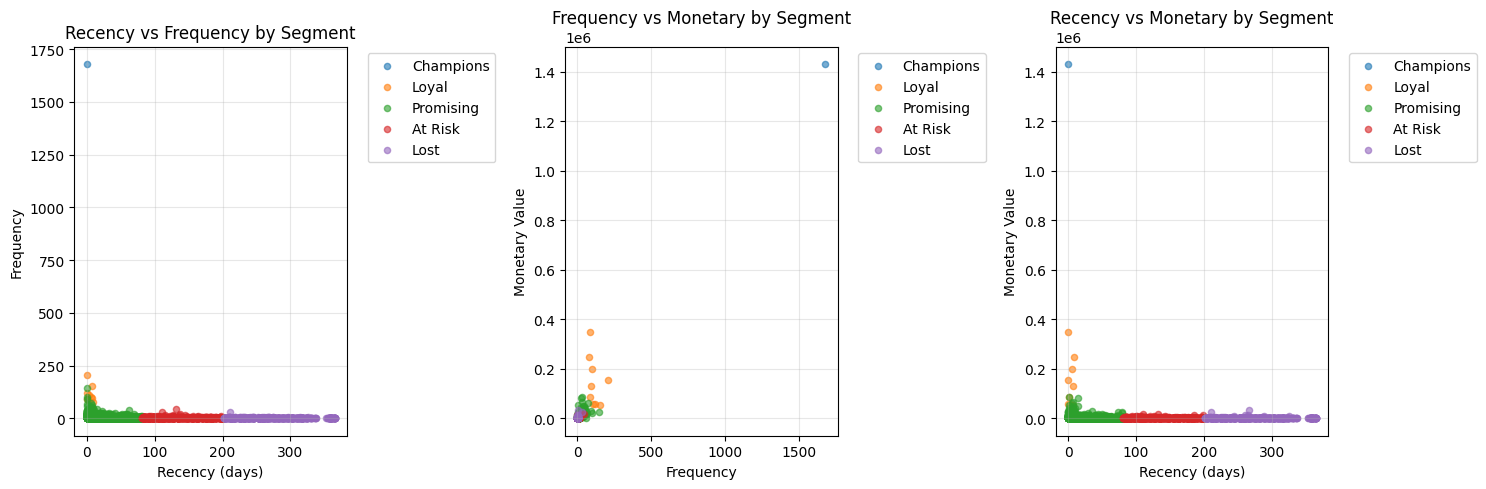

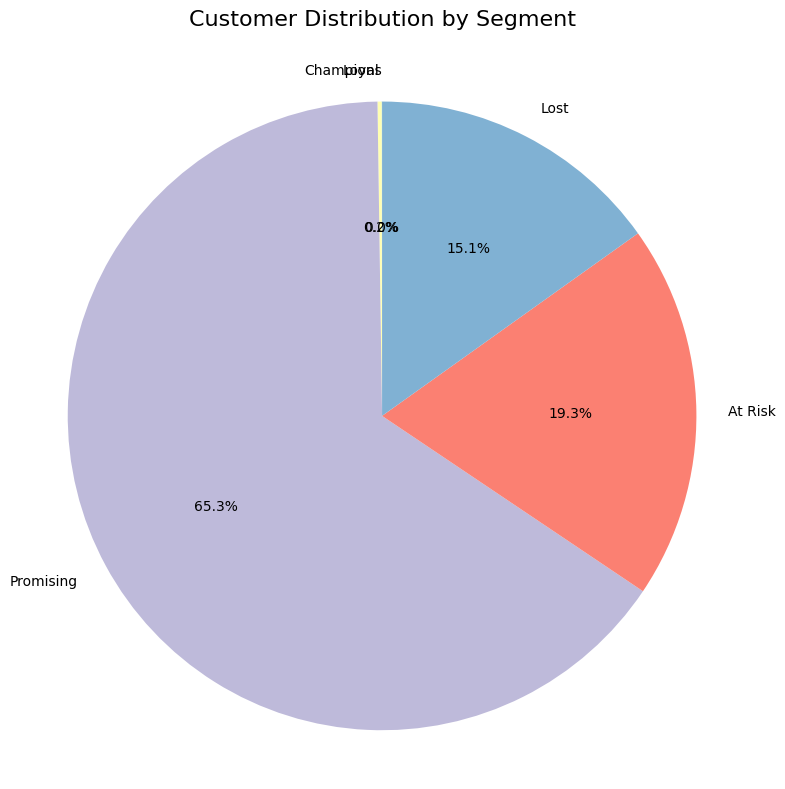

26/04/21 22:26:10 WARN TaskSetManager: Stage 1967 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:26:18 WARN TaskSetManager: Stage 1977 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:26:27 WARN TaskSetManager: Stage 1998 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


MODEL EVALUATION SUMMARY
Total customers segmented:    4,274
Champions segment coverage:   0.0%
Clusters found:               5
High-value segment captured: 0.0% of customers



CHAMPIONS SEGMENT PROFILE
  Avg Recency:     0.0 days
  Avg Frequency:   1679.0
  Avg Monetary:    £1431040.97
  Top 5% Monetary: £1431040.97

Visualization & evaluation complete
Files saved: rfm_segments_visualization.png, segment_distribution_pie.png


In [12]:
log.info("SEGMENT ANALYSIS & VISUALIZATION")

# Segment distribution
segment_stats = labeled_df.groupBy("segment").agg(
    F.count("*").alias("customers"),
    F.round(F.mean("Recency"), 1).alias("avg_recency_days"),
    F.round(F.mean("Frequency"), 1).alias("avg_frequency"),
    F.round(F.mean("Monetary"), 2).alias("avg_monetary")
).orderBy(F.desc("avg_monetary"))

stats_pd = segment_stats.toPandas()
print("Segment Statistics:")
print(stats_pd.to_string(index=False))
print()

# Visualize RFM by segment (3D scatter plot)
pandas_rfm = labeled_df.select("Recency", "Frequency", "Monetary", "segment").toPandas()

fig = plt.figure(figsize=(15, 5))

# Recency vs Frequency
ax1 = plt.subplot(1, 3, 1)
for segment in stats_pd['segment']:
    seg_data = pandas_rfm[pandas_rfm['segment'] == segment]
    ax1.scatter(seg_data['Recency'], seg_data['Frequency'], 
               label=segment, alpha=0.6, s=20)
ax1.set_xlabel('Recency (days)')
ax1.set_ylabel('Frequency')
ax1.set_title('Recency vs Frequency by Segment')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Frequency vs Monetary
ax2 = plt.subplot(1, 3, 2)
for segment in stats_pd['segment']:
    seg_data = pandas_rfm[pandas_rfm['segment'] == segment]
    ax2.scatter(seg_data['Frequency'], seg_data['Monetary'], 
               label=segment, alpha=0.6, s=20)
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Monetary Value')
ax2.set_title('Frequency vs Monetary by Segment')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# Recency vs Monetary
ax3 = plt.subplot(1, 3, 3)
for segment in stats_pd['segment']:
    seg_data = pandas_rfm[pandas_rfm['segment'] == segment]
    ax3.scatter(seg_data['Recency'], seg_data['Monetary'], 
               label=segment, alpha=0.6, s=20)
ax3.set_xlabel('Recency (days)')
ax3.set_ylabel('Monetary Value')
ax3.set_title('Recency vs Monetary by Segment')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rfm_segments_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

# Pie chart: Customer distribution by segment
plt.figure(figsize=(8, 8))
colors = plt.cm.Set3(range(len(stats_pd)))
wedges, texts, autotexts = plt.pie(
    stats_pd['customers'], 
    labels=stats_pd['segment'], 
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
plt.title('Customer Distribution by Segment', fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig("segment_distribution_pie.png", dpi=150, bbox_inches='tight')
plt.show()

# Model quality metrics
total_customers = labeled_df.count()
champions_pct = (labeled_df.filter(F.col("segment") == "Champions").count() / total_customers) * 100

print("MODEL EVALUATION SUMMARY")
print(f"Total customers segmented:    {total_customers:,}")
print(f"Champions segment coverage:   {champions_pct:.1f}%")
# print(f"Silhouette score (test):      {evaluator.evaluate(test_preds):.4f}")
print(f"Clusters found:               {5}") # We hardcoded k=5 for business interpretability
print(f"High-value segment captured: {champions_pct:.1f}% of customers")

# 5. Champions segment profile
champions_profile = labeled_df.filter(F.col("segment") == "Champions").agg(
    F.round(F.mean("Recency"), 1).alias("avg_recency"),
    F.round(F.mean("Frequency"), 1).alias("avg_frequency"),
    F.round(F.mean("Monetary"), 2).alias("avg_monetary"),
    F.round(F.percentile_approx("Monetary", 0.95), 2).alias("p95_monetary")
).collect()[0]

print(f"\nCHAMPIONS SEGMENT PROFILE")
print(f"  Avg Recency:     {champions_profile['avg_recency']} days")
print(f"  Avg Frequency:   {champions_profile['avg_frequency']}")
print(f"  Avg Monetary:    £{champions_profile['avg_monetary']}")
print(f"  Top 5% Monetary: £{champions_profile['p95_monetary']}")

print("\nVisualization & evaluation complete")
print("Files saved: rfm_segments_visualization.png, segment_distribution_pie.png")

## Export Champion and At Risk Segments

In [17]:
def export_segment(labeled: DataFrame, segment_name: str, total_customers: int) -> None:
    segment_df = labeled.filter(F.col("segment") == segment_name)
    count = segment_df.count()
    
    (
        segment_df
        .select("Customer ID", "Country", "Recency", "Frequency", "Monetary", "segment")
        .coalesce(1)  # Single file output for CSV
        .write.csv(CFG.output_dir, header=True, mode="overwrite")
    )
    
    log.info(
        "Exported %d '%s' customers (%.1f%% of total) → %s",
        count,
        segment_name,
        100 * count / max(total_customers, 1),
        CFG.output_dir,
    )

total_customers = rfm_df.count()
export_segment(labeled_df, CFG.top_segment_name, total_customers) # We can also export other segments by changing the segment_name argument
print("Champions segment exported")

26/04/21 22:34:16 WARN TaskSetManager: Stage 2389 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:34:24 WARN TaskSetManager: Stage 2399 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:34:33 WARN TaskSetManager: Stage 2420 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:34:42  INFO      Exported 1 'Champions' customers (0.0% of total) → ../data/outputs/customer_segments
Champions segment exported


In [18]:
export_segment(labeled_df, CFG.bottom_segment_name, total_customers)
print("At Risk segment exported")

26/04/21 22:34:42 WARN TaskSetManager: Stage 2435 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:34:50 WARN TaskSetManager: Stage 2456 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:34:58  INFO      Exported 824 'At Risk' customers (19.3% of total) → ../data/outputs/customer_segments
At Risk segment exported


## Close Spark Session

In [19]:
spark.stop()
print("Spark session stopped")

Spark session stopped
